# Large Language Models (LLMs) for Text Classification Benchmark

**Author:** Alireza Mirzadeh  
**Project:** LLM Text Classification Benchmark  
**Dataset:** Rotten Tomatoes (Hugging Face Datasets)  
**Notebook:** 02 — Baseline Models

---

## Project Overview

This project provides a comprehensive benchmark of text classification techniques, progressing from classical machine learning methods to transformer-based models and large language models (LLMs). The implementation emphasizes reproducibility, modular software design, and rigorous experimental evaluation.

### Project Links

- **GitHub Repository:** *[llm-text-classification-benchmark](https://github.com/Alireza-Mirzadeh/llm-text-classification-benchmark)*

- **LinkedIn:** *[Alireza Mirzadeh](https://www.linkedin.com/in/alireza-mirzadeh/)*

---

# Classical Machine Learning Models for Text Classification 

## Objective

In this notebook, we will implement and evaluate classical machine learning models for text classification. The goal is to establish baseline performance metrics that can be compared against more advanced models in subsequent notebooks.

We will focus on the following classical models:
- Logistic Regression + TF-IDF
- Logistic Regression + Bag-of-Words
- Support Vector Machines (SVM) + TF-IDF

The evaluation will be based on accuracy, precision, recall, and F1-score metrics. The results will be saved to a CSV file for further analysis and comparison.

In [63]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

# 0- Data Preparation

In [64]:
from src.data_loader import RottenTomatoesDataLoader

from src.baselines import MajorityClassBaseline
from src.evaluation import evaluate_classifier, plot_confusion_matrix

import matplotlib.pyplot as plt
import pandas as pd

FIGURES_DIR = Path("../reports/figures/eda")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [65]:
# Load the Rotten Tomatoes dataset using the data_loader from the src
loader = RottenTomatoesDataLoader()

dataset = loader.load_dataset_local()

2026-07-11 20:35:02,657 - INFO - Loading dataset from local_path: /home/alireza/Work/llm-text-classification-benchmark/data/raw/rotten_tomatoes


In [66]:
# Create train, validation, and test splits
train_ds = dataset["train"]
validation_ds = dataset["validation"]
test_ds = dataset["test"]

# Convert to pands DataFrames
train_df = train_ds.to_pandas()
validation_df = validation_ds.to_pandas()
test_df = test_ds.to_pandas()

print(f"Train dataset shape: {train_df.shape}")
print(f"Validation dataset shape: {validation_df.shape}")
print(f"Test dataset shape: {test_df.shape}")

Train dataset shape: (8530, 2)
Validation dataset shape: (1066, 2)
Test dataset shape: (1066, 2)


In [67]:
# Display class distribution for each split
for split_name, split_df in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    print(
        f"{split_name.capitalize()} dataset class distribution: \n\n{split_df['label'].value_counts(normalize=True)}\n"
    )


Train dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64

Validation dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64

Test dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64



# 1- Train and evaluate the majority class baseline model

In [68]:
# Seprate features and labels for each split
X_train, y_train = train_df["text"], train_df["label"]

X_test, y_test = test_df["text"], test_df["label"]


In [69]:
# Train the Majority Class Baseline model
baseline = MajorityClassBaseline()
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)

Baseline Model Metrics:
accuracy: 0.50
precision: 0.00
recall: 0.00
f1: 0.00


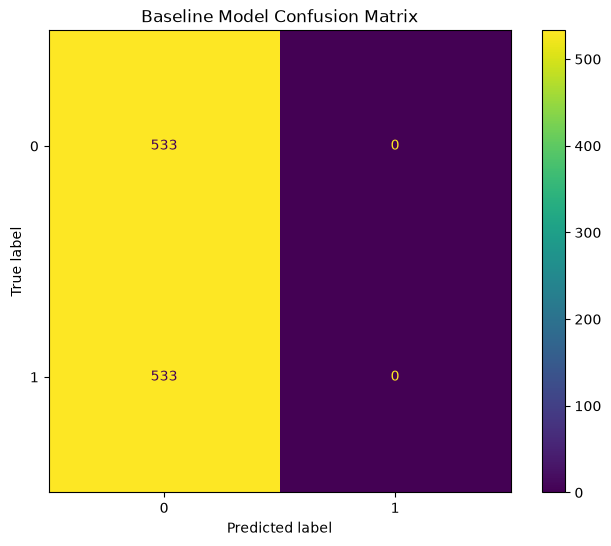

In [70]:
# Evaluate the model
metrics, report = evaluate_classifier(y_test, y_pred)

print("Baseline Model Metrics:")

for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.2f}")

confusion_matrix = plot_confusion_matrix("Baseline Model", y_test, y_pred)


In [71]:
# Add the results to a DataFrame for comparison with other models
results = []
results.append(
    {
        "model": "Majority Class Baseline",
        **metrics,
    }
)

benchmark_df = pd.DataFrame(results)
benchmark_df


,model,accuracy,precision,recall,f1
0,Majority Class Baseline,0.5,0.0,0.0,0.0


The majority-class baseline achieved an accuracy of 50%, which is expected given the balanced class distribution of the Rotten Tomatoes dataset. As the model always predicts the majority class, it fails to calculate precision, recall, and F1-score resulting in 0 for these metrics. This baseline establishes the minimum level of performance that any meaningful classifier should exceed.

# 3- Train the Bag of Words with Logistic Regression model

In [72]:
from src.models.bow_lr import BagOfWordsClassifier


In [73]:
# Train the Bag of Words Classifier with Logistic Regression
bow_lr = BagOfWordsClassifier()

bow_lr.fit(X_train, y_train)

y_pred_bow_lr = bow_lr.predict(X_test)

# Evaluate the Bag of Words model
metrics_bow_lr, report_bow_lr = evaluate_classifier(y_test, y_pred_bow_lr)

print("Bag-of-Words + Logistic Regression:")

for metric_name, metric_value in metrics_bow_lr.items():
    print(f"{metric_name}: {metric_value:.2f}")
    

Bag-of-Words + Logistic Regression:
accuracy: 0.77
precision: 0.77
recall: 0.76
f1: 0.77


In [74]:
report_df_bow_lr = pd.DataFrame(report_bow_lr).transpose()

report_df_bow_lr

,precision,recall,f1-score,support
negative,0.765250,0.776735,0.770950,533.000000
positive,0.773333,0.761726,0.767486,533.000000
accuracy,0.769231,0.769231,0.769231,0.769231
macro avg,0.769291,0.769231,0.769218,1066.000000
weighted avg,0.769291,0.769231,0.769218,1066.000000


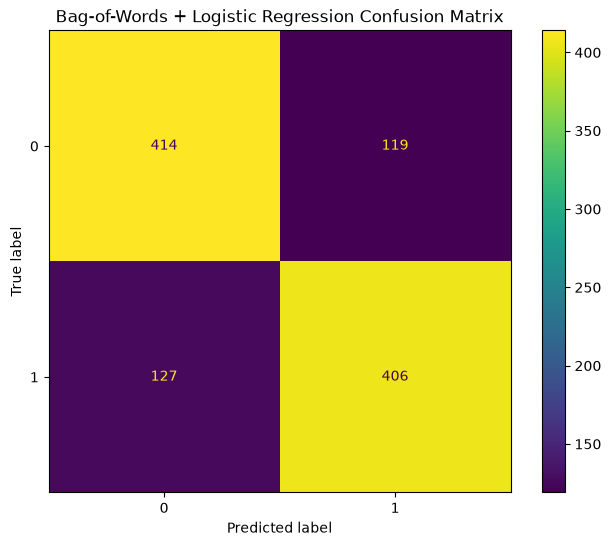

In [75]:
# Confiusion matrix for Bag of Words model
plot_confusion_matrix("Bag-of-Words + Logistic Regression", y_test, y_pred_bow_lr)

plt.show()


In [76]:
# Append the Bag of Words model results to the benchmark DataFrame

results.append(
    {
        "model": "Bag-of-Words + Logistic Regression",
        **metrics_bow_lr,
    }
)

benchmark_df = pd.DataFrame(results)
benchmark_df


,model,accuracy,precision,recall,f1
0,Majority Class Baseline,0.500000,0.000000,0.000000,0.000000
1,Bag-of-Words + Logistic Regression,0.769231,0.773333,0.761726,0.767486


# 4- Train TF-IDF with Logistic Regression model

In [77]:
from src.models.tfidf_lr import TfidfClassifier


In [78]:
# Train the TF-IDF Classifier with Logistic Regression
tfidf_lr = TfidfClassifier()

tfidf_lr.fit(X_train, y_train)

y_pred_tfidf_lr = tfidf_lr.predict(X_test)

# Evaluate the TF-IDF model
metrics_tfidf_lr, report_tfidf_lr = evaluate_classifier(y_test, y_pred_tfidf_lr)

print("TF-IDF + Logistic Regression:")

for metric_name, metric_value in metrics_tfidf_lr.items():
    print(f"{metric_name}: {metric_value:.2f}")
    

TF-IDF + Logistic Regression:
accuracy: 0.78
precision: 0.78
recall: 0.78
f1: 0.78


In [79]:
report_df_tfidf_lr = pd.DataFrame(report_tfidf_lr).transpose()

report_df_tfidf_lr

,precision,recall,f1-score,support
negative,0.778399,0.784240,0.781308,533.000000
positive,0.782609,0.776735,0.779661,533.000000
accuracy,0.780488,0.780488,0.780488,0.780488
macro avg,0.780504,0.780488,0.780485,1066.000000
weighted avg,0.780504,0.780488,0.780485,1066.000000


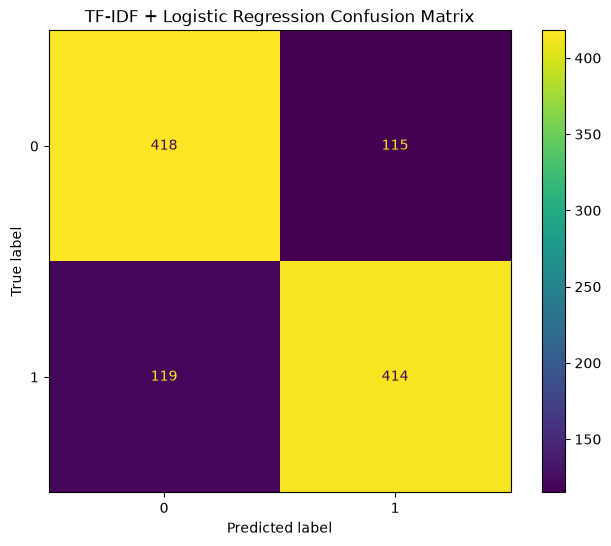

In [80]:
# Confusion matrix for TF-IDF model
plot_confusion_matrix(
    "TF-IDF + Logistic Regression",
    y_test,
    y_pred_tfidf_lr
)
plt.show()

In [81]:
# Add the TF-IDF model results to the benchmark DataFrame
results.append(
    {
        "model": "TF-IDF + Logistic Regression",
        **metrics_tfidf_lr,
    }
)

benchmark_df = pd.DataFrame(results)
benchmark_df


,model,accuracy,precision,recall,f1
0,Majority Class Baseline,0.500000,0.000000,0.000000,0.000000
1,Bag-of-Words + Logistic Regression,0.769231,0.773333,0.761726,0.767486
2,TF-IDF + Logistic Regression,0.780488,0.782609,0.776735,0.779661


# Discussion: Bag of Words vs. TF-IDF

The TF-IDF representation achieved a slightly higher performance than the Bag-of-Words model. Although the imporovement is modest, it demonstrates the advantage of weighting words according to their importance within the corpus rather than relying solely on raw occurence counts.

Bag-of-Words assigns equal importance to all words, regardless of how frequently they appear across the dataset. In contrast, TF_IDF reduces the infulence of very common terms while emphasizing words that are more discriminative for classification. As a result, the classifier is able to focus more on informative words.

The relatively small performance gain suggests that the Rotten Tomatoes dataset is already well-suited to simple lexical representations. Because the reviews are generally short and expresse sentiment using direct language, raw word counts already provide a strong baseline.

The next experiment investigates whether incorporating richer decision boundaries through a different classifier can further improve perfrormance while using the same TF-IDF representation.


# 5- Train TF-IDF with Support Vector Machine (SVM) model

In [82]:
from src.models.tfidf_svm import TFIDFLinearSVM


In [83]:
# Train the TF-IDF with Linear SVM Classifier
tfidf_svm = TFIDFLinearSVM()

tfidf_svm.fit(X_train, y_train)

y_pred_tfidf_svm = tfidf_svm.predict(X_test)

# Evaluate the TF-IDF with Linear SVM model
metrics_tfidf_svm, report_tfidf_svm = evaluate_classifier(y_test, y_pred_tfidf_svm)

print("TF-IDF + Linear SVM:")

for metric_name, metric_value in metrics_tfidf_svm.items():
    print(f"{metric_name}: {metric_value:.2f}")


TF-IDF + Linear SVM:
accuracy: 0.76
precision: 0.77
recall: 0.75
f1: 0.76


In [84]:
report_df_tfidf_svm = pd.DataFrame(report_tfidf_svm).transpose()

report_df_tfidf_svm

,precision,recall,f1-score,support
negative,0.754545,0.778612,0.766390,533.000000
positive,0.771318,0.746717,0.758818,533.000000
accuracy,0.762664,0.762664,0.762664,0.762664
macro avg,0.762932,0.762664,0.762604,1066.000000
weighted avg,0.762932,0.762664,0.762604,1066.000000


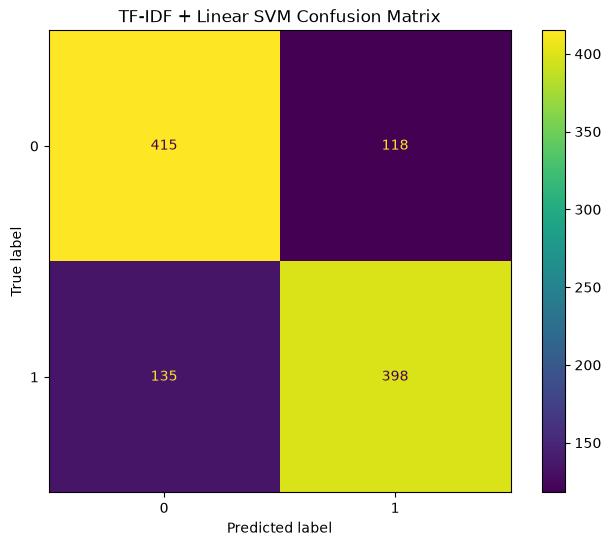

In [85]:
# Confusion matrix for Tf-IDF with Linear SVM model
plot_confusion_matrix("TF-IDF + Linear SVM", y_test, y_pred_tfidf_svm)
plt.show()


In [86]:
# Add the TF-IDF wiht Linear SVM model results to the benchmark DataFrame
results.append({"model": "TF-IDF + Linear SVM", **metrics_tfidf_svm})

benchmark_df = pd.DataFrame(results)
benchmark_df


,model,accuracy,precision,recall,f1
0,Majority Class Baseline,0.500000,0.000000,0.000000,0.000000
1,Bag-of-Words + Logistic Regression,0.769231,0.773333,0.761726,0.767486
2,TF-IDF + Logistic Regression,0.780488,0.782609,0.776735,0.779661
3,TF-IDF + Linear SVM,0.762664,0.771318,0.746717,0.758818


# 6- Classical Machine Learning Models Summary

In [87]:
# Sort the benchmark DataFrame by F1 score in descending order and reset the index
benchmark_df = (
    pd.DataFrame(results)
    .sort_values(by="f1", ascending=False)
    .reset_index(drop=True)
)

# Set the index to start from 1 and rename the index column to "Rank"
benchmark_df.index += 1
benchmark_df.index.name = "Rank"

# Round the metrics to 3 decimal places for better readability
benchmark_df = benchmark_df.round(3)


In [91]:
# Save the benchmark results to a CSV file
benchmark_df.to_csv("../reports/results/benchmark_results.csv", index=True)


In [89]:
# Display the benchmark results in a styled table
styled_benchmark = (
    benchmark_df.style.highlight_max(
        subset=["accuracy", "precision", "recall", "f1"], color="#5EC46F3D"
    )
    .set_properties(**{"text-align": "center"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [("font-size", "13pt")],
            },
            {
                "selector": "caption",
                "props": [
                    ("font-size", "16pt"),
                    ("font-weight", "bold"),
                ],
            },
        ]
    )
    .set_caption("Table 1. Benchmark of Classical Machine Learning Models")
)

styled_benchmark


,model,accuracy,precision,recall,f1
Rank,,,,,
1,TF-IDF + Logistic Regression,0.780000,0.783000,0.777000,0.780000
2,Bag-of-Words + Logistic Regression,0.769000,0.773000,0.762000,0.767000
3,TF-IDF + Linear SVM,0.763000,0.771000,0.747000,0.759000
4,Majority Class Baseline,0.500000,0.000000,0.000000,0.000000


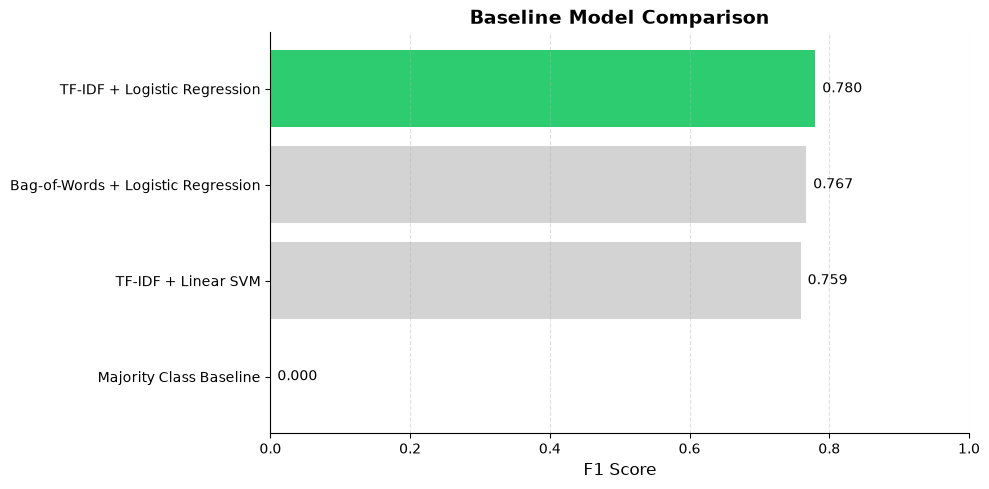

In [90]:
# Visualize the benchmark results using a horizontal bar chart

benchmark_df = benchmark_df.sort_values(by="f1", ascending=True)

# Highlight the best model
colors = [
    "#D3D3D3" if f1 != benchmark_df["f1"].max() else "#2ECC71"
    for f1 in benchmark_df["f1"]
]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    benchmark_df["model"],
    benchmark_df["f1"],
    color=colors
)

# Labels on bars

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

# Formatting

ax.set_xlim(0, 1)

ax.set_xlabel("F1 Score", fontsize=12)

ax.set_ylabel("")

ax.set_title(
    "Baseline Model Comparison",
    fontsize=14,
    fontweight="bold",
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Light grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4,
)

plt.tight_layout()

# Save figure

figure_path = FIGURES_DIR / "baseline_model_comparison.png"

fig.savefig(
    figure_path,
)

plt.show()


# Discussion and Conclusions

This benchmark compared three classical machine learning approaches for binary sentiment classification on the Rotten Tomatoes dataset. The majority class baseline established a reference accuracy of 50%, confirming that the dataset is approximately balanced and that meaningful models must substantially exceed random or majority-class predictions.

Among the evaluated approaches, TF-IDF combined with Logistic Regression achieved the best overall performance, reaching an accuracy and F1-score of 0.78. Compared with the Bag-of-Words representation, TF-IDF provided a modest but consistent improvement, demonstrating the value of weighting terms according to their importance within the corpus rather than relying solely on raw frequency counts.

Interestingly, the TF-IDF + Linear SVM model produced slightly lower performance than Logistic Regression under the default hyperparameter configuration. Although Linear SVM is widely regarded as one of the strongest traditional text classifiers, this result illustrates that model performance is data-dependent and that default hyperparameters are not always optimal. Future work could investigate whether hyperparameter tuning improves the SVM's performance.

Overall, these experiments establish strong classical machine learning baselines for sentiment classification. The next stage of the project will investigate transformer-based language models, which leverage contextual word representations and are expected to outperform sparse lexical feature representations on this task.